In [5]:
import pandas as pd

In [6]:
train = pd.read_csv('../data/raw_data/train.csv', parse_dates=['Date'], dtype={'StateHoliday': str})
store = pd.read_csv('../data/raw_data/store.csv')

In [7]:
train.shape

(1017209, 9)

In [8]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [9]:
store = pd.read_csv('../data/raw_data/store.csv')

In [10]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [11]:
store.shape

(1115, 10)

In [12]:
df = train.merge(store,on='Store' , how='left')

In [13]:
df.shape

(1017209, 18)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

In [14]:
df.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df['Sales'].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

In [17]:
df[df['Sales'] == 0]['Open'].value_counts()

Open
0    172817
1        54
Name: count, dtype: int64

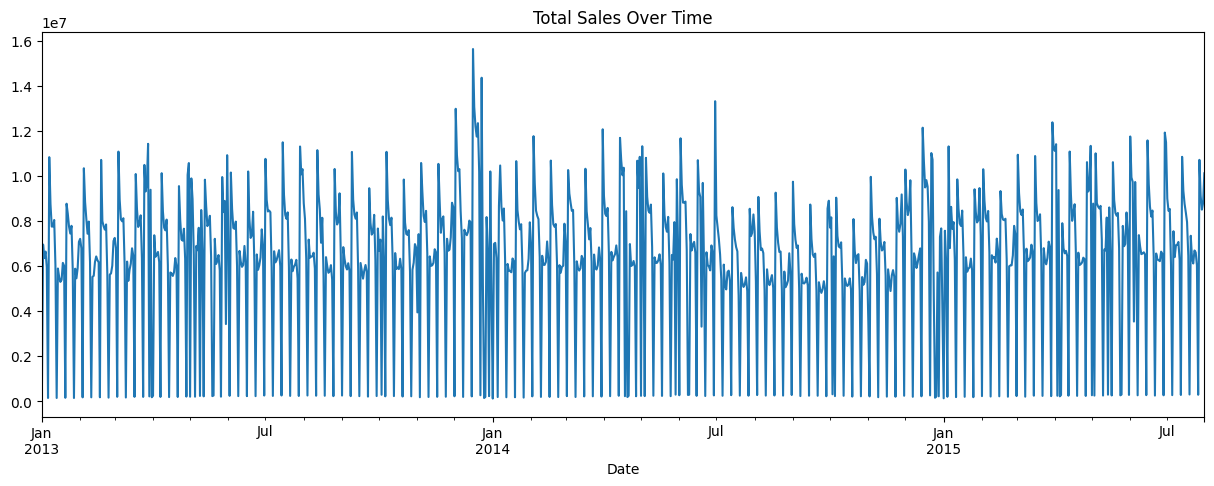

In [18]:
df.groupby('Date')['Sales'].sum().plot(figsize=(15,5), title='Total Sales Over Time')
plt.show()

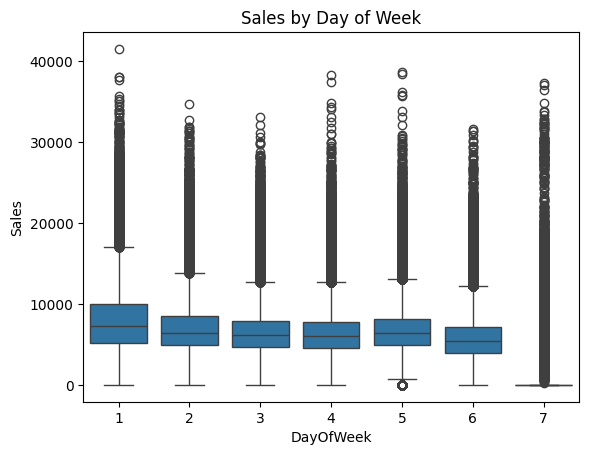

In [21]:
sns.boxplot(x='DayOfWeek', y='Sales', data=df)
plt.title('Sales by Day of Week')
plt.show()

In [22]:
df.groupby('Promo')['Sales'].mean()

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64

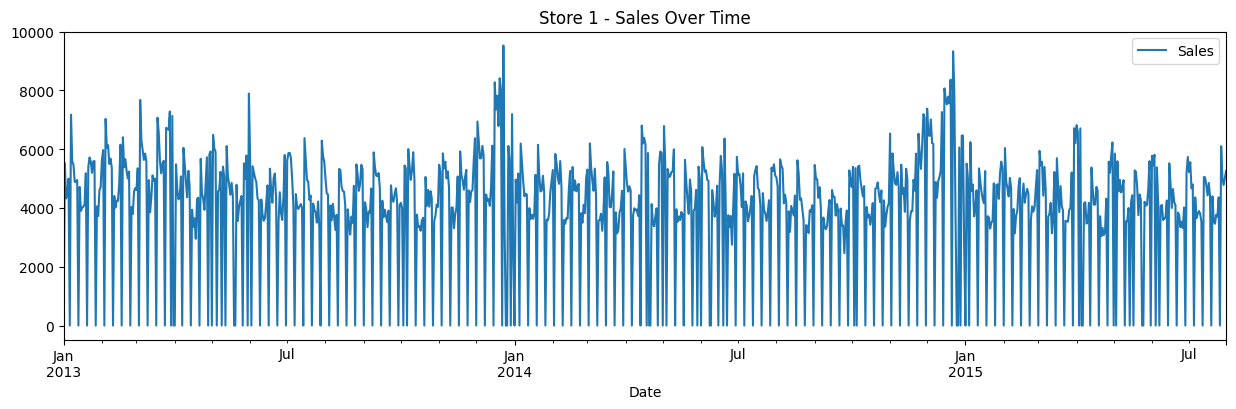

In [23]:
store_1 = df[df['Store'] == 1]
store_1.plot(x='Date', y='Sales', figsize=(15,4), title='Store 1 - Sales Over Time')
plt.show()

In [24]:
df = df[df['Open'] == 1].copy()
df.shape

(844392, 18)

In [25]:
# df['StateHoliday'] = df['StateHoliday'].astype(str)
df['StateHoliday'].value_counts()

StateHoliday
0    843482
a       694
b       145
c        71
Name: count, dtype: int64

In [26]:
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())

In [27]:
df['CompetitionDistance'].isnull().sum()

np.int64(0)

In [28]:
df[['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear']].isnull().sum()

CompetitionOpenSinceMonth    268619
CompetitionOpenSinceYear     268619
dtype: int64

In [29]:
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0)

In [30]:
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0)

In [31]:
df[['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear']].isnull().sum()

CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
dtype: int64

In [32]:
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)
df['PromoInterval'] = df['PromoInterval'].fillna('None')

In [33]:
df.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

In [34]:
df.to_csv('../data/processed_data/cleaned_sales_data.csv', index=False)

In [35]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

In [36]:
df[['Date', 'Year', 'Month', 'Day', 'WeekOfYear']].head()

,Date,Year,Month,Day,WeekOfYear
0,2015-07-31,2015,7,31,31
1,2015-07-31,2015,7,31,31
2,2015-07-31,2015,7,31,31
3,2015-07-31,2015,7,31,31
4,2015-07-31,2015,7,31,31


In [37]:
df['IsWeekend'] = df['DayOfWeek'].isin([6, 7]).astype(int)

In [38]:
df[['DayOfWeek', 'IsWeekend']].drop_duplicates()

,DayOfWeek,IsWeekend
0,5,0
1115,4,0
2230,3,0
3345,2,0
4460,1,0
5659,7,1
6690,6,1


In [39]:
df = df.sort_values(['Store', 'Date'])

In [40]:
df[['Store', 'Date']].head(15)

,Store,Date
1014980,1,2013-01-02
1013865,1,2013-01-03
1012750,1,2013-01-04
1011635,1,2013-01-05
1009405,1,2013-01-07
1008290,1,2013-01-08
1007175,1,2013-01-09
1006060,1,2013-01-10
1004945,1,2013-01-11
1003830,1,2013-01-12


In [41]:
df['Sales_Lag_7'] = df.groupby('Store')['Sales'].shift(7)

In [42]:
df[['Store', 'Date', 'Sales', 'Sales_Lag_7']].head(10)

,Store,Date,Sales,Sales_Lag_7
1014980,1,2013-01-02,5530,NaN
1013865,1,2013-01-03,4327,NaN
1012750,1,2013-01-04,4486,NaN
1011635,1,2013-01-05,4997,NaN
1009405,1,2013-01-07,7176,NaN
1008290,1,2013-01-08,5580,NaN
1007175,1,2013-01-09,5471,NaN
1006060,1,2013-01-10,4892,5530.0
1004945,1,2013-01-11,4881,4327.0
1003830,1,2013-01-12,4952,4486.0


In [43]:
df['Sales_RollingMean_7'] = df.groupby('Store')['Sales'].shift(1).rolling(7).mean()

In [44]:
df[['Store', 'Date', 'Sales', 'Sales_RollingMean_7']].head(10)

,Store,Date,Sales,Sales_RollingMean_7
1014980,1,2013-01-02,5530,NaN
1013865,1,2013-01-03,4327,NaN
1012750,1,2013-01-04,4486,NaN
1011635,1,2013-01-05,4997,NaN
1009405,1,2013-01-07,7176,NaN
1008290,1,2013-01-08,5580,NaN
1007175,1,2013-01-09,5471,NaN
1006060,1,2013-01-10,4892,5366.714286
1004945,1,2013-01-11,4881,5275.571429
1003830,1,2013-01-12,4952,5354.714286


In [45]:
df = df.dropna(subset=['Sales_Lag_7', 'Sales_RollingMean_7'])
df.shape

(836587, 25)

In [46]:
df.to_csv('../data/processed_data/featured_sales_data.csv', index=False)